In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sns.set_theme(style="whitegrid")

If snakemake has not finished running completely,
This cell will aggregate the raw results into a table instead of reading the aggregated file.

In [2]:
experiment_1_path = "../results_raw/leaf_n10_experiment1/"
agg_for_nb = "exp1_nb_agg.csv"

with open(agg_for_nb, "w") as f_w:
    for result_path in glob.glob(experiment_1_path + "*/*"):
        with open(result_path, "r") as f_r:
            f_w.write(f_r.read())

In [3]:
csv_path = agg_for_nb
header = ["network_path", "algorithm", "time", "is_tc"]

df = pd.read_csv(csv_path, names=header)
df["nw_id"]=df["network_path"].apply(lambda x: x.split("/")[-1])
df["reticulations"]=df["network_path"].apply(lambda x: int(x.split("/")[-2][-1]))
df

,network_path,algorithm,time,is_tc,nw_id,reticulations
0,data/leaf_n10_experiment1/leaf_n10_reticulatio...,TCO_CB,0.031728,True,10_0.15_209_binary_adj.csv,3
1,data/leaf_n10_experiment1/leaf_n10_reticulatio...,PR_BF,0.142094,True,10_0.15_210_binary_adj.csv,3
2,data/leaf_n10_experiment1/leaf_n10_reticulatio...,PR_FPT,0.048565,True,10_0.15_210_binary_adj.csv,3
3,data/leaf_n10_experiment1/leaf_n10_reticulatio...,TCO_H,0.008336,True,10_0.15_209_binary_adj.csv,3
4,data/leaf_n10_experiment1/leaf_n10_reticulatio...,PR_FPT_CB_CHOOSE,0.038874,True,10_0.15_210_binary_adj.csv,3
...,...,...,...,...,...,...
210,data/leaf_n10_experiment1/leaf_n10_reticulatio...,TCO_H_F,0.012540,True,10_0.15_212_binary_adj.csv,4
211,data/leaf_n10_experiment1/leaf_n10_reticulatio...,TCO_H_F,0.015962,True,10_0.15_213_binary_adj.csv,4
212,data/leaf_n10_experiment1/leaf_n10_reticulatio...,TCO_H_F,0.020006,True,10_0.15_215_binary_adj.csv,4
213,data/leaf_n10_experiment1/leaf_n10_reticulatio...,TCO_H_F,0.021597,True,10_0.15_214_binary_adj.csv,4


[None]

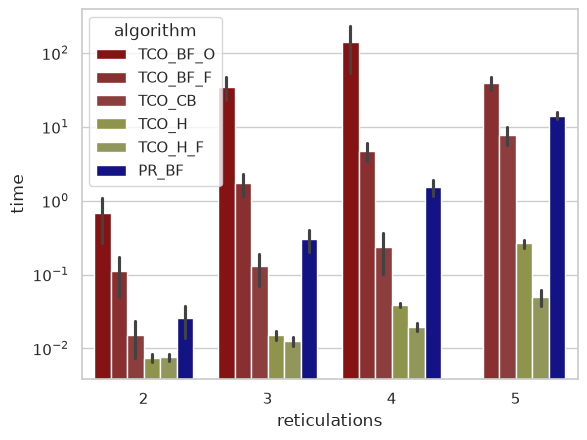

In [8]:
algorithms = ["TCO_BF_O", "TCO_BF_F", "TCO_CB", "TCO_H", "TCO_H_F", "PR_BF"]#, "TCO_BF", "PR_FPT", "PR_FPT_CB_CHOOSE", "PR_FPT_CB_COMB", "PR_FPT_CB_PROD"]
algo_colors = {
    "TCO_BF_O": "#990000", "TCO_BF": "#991010", "TCO_BF_F": "#992020", "TCO_CB": "#993030", "TCO_H": "#99A040", "TCO_H_F": "#99A050", "PR_BF": "#000099", "PR_FPT": "#202099", "PR_FPT_CB_CHOOSE": "#404099", "PR_FPT_CB_COMB": "#606099", "PR_FPT_CB_PROD": "#808099"
}

df_selected = df[df["algorithm"].isin(algorithms)]
sns.barplot(df_selected, y="time", x="reticulations", hue="algorithm", hue_order=algorithms, errorbar="se", palette=algo_colors).set(yscale = 'log')